# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

import pickle

In [2]:
import pandas as pd 
import numpy as np

In [3]:
from scipy.stats import norm, invgamma
# estimators
# from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS
from sklearn.linear_model import LinearRegression, Lasso

from scipy.integrate import quad 
from scipy.stats import ks_2samp

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [5]:
from core.variables import * 
from core.dgp import *

import core.continuous_segment as cs 

# DGP

$$
\begin{aligned}
Y_i & = \alpha'X_i T_i + \beta'X_i + \epsilon_i \\ 
\end{aligned}
$$

In [6]:
dgp_params = {
    'treatment_space': np.array([1, 2]),
    'n_features': 1,
    'alpha_lb': 0.5, 'alpha_ub': 1.5,
    'beta_lb': 1, 'beta_ub': 3,
    'noise_std': 2, 'const': 5, 
    'seed': 0
}

dgp = ContinuousSegments(**dgp_params)

In [7]:
X_train, T_train, Y_train = dgp.sample(5000, seed=0)
X_test, T_test, Y_test = dgp.sample(1000, seed=1)

# Demand Model

In [8]:
clr = cs.CorrectLinearRegression(dgp.treatment_space).fit(X_train, T_train, Y_train)
segment_model = cs.SegmentModel(dgp.treatment_space, threshold=0).fit(X_train, T_train, Y_train)

      correct_model  segment_model
rmse       2.070781       3.236288
r2         0.791550       0.490870
mape       1.530316       1.735133


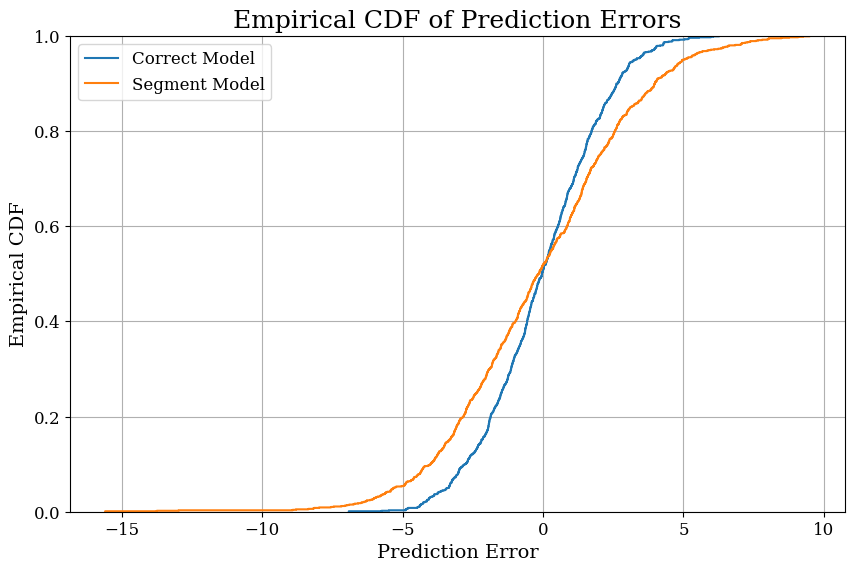

In [9]:
def evaluate_demand_model(demand_model, X: np.ndarray, T: np.ndarray, Y: np.ndarray):
    y_pred = demand_model.predict(X, T)

    rmse = np.sqrt(np.mean((y_pred - Y) ** 2))
    r2 = 1 - np.sum((Y - y_pred) ** 2) / np.sum((Y - np.mean(Y)) ** 2)
    mape = np.mean(np.abs((Y - y_pred) / Y))

    return {
        'rmse': rmse, 
        'r2': r2, 
        'mape': mape
    }

performance_df = pd.DataFrame({
    'correct_model': evaluate_demand_model(clr, X_test, T_test, Y_test),
    'segment_model': evaluate_demand_model(segment_model, X_test, T_test, Y_test),
})

print(performance_df)

# plot empirical CDF of prediction errors
fig, ax = plt.subplots(figsize=(10, 6.18))

for idx, (demand_model_name, demand_model) in enumerate(zip(['Correct Model', 'Segment Model'], [clr, segment_model])):
    y_pred = demand_model.predict(X_test, T_test)
    sns.ecdfplot(y_pred - Y_test, ax=ax, color=f'C{idx}', label=demand_model_name)

ax.set_title('Empirical CDF of Prediction Errors', fontsize=title_size)
ax.set_xlabel('Prediction Error', fontsize=axis_label_size)
ax.set_ylabel('Empirical CDF', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()

plt.show()

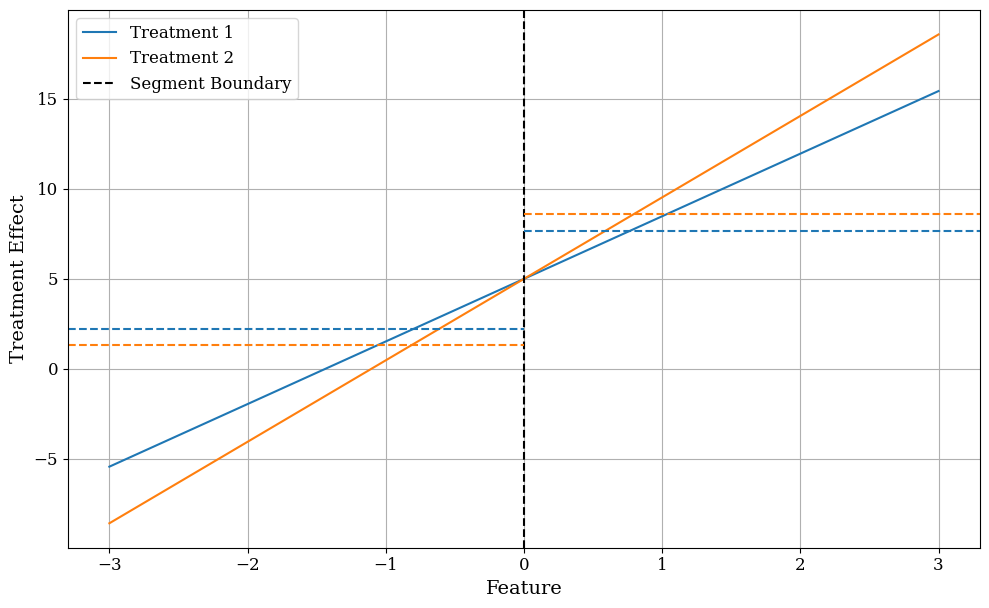

In [10]:
x_space = np.linspace(-3, 3, 10000)[:, np.newaxis]
t1_arr = dgp.predict(x_space, np.ones(x_space.shape[0]))
t2_arr = dgp.predict(x_space, 2 * np.ones(x_space.shape[0]))

fig, ax = plt.subplots(figsize=(10, 6.18))

ax.plot(x_space, t1_arr, label='Treatment 1', color='C0')
ax.plot(x_space, t2_arr, label='Treatment 2', color='C1')

ax.axvline(segment_model.threshold, color='k', linestyle='--', label='Segment Boundary')

# estimated treatment effect of segment 1 treatment 1
viz_threshold = (3 + segment_model.threshold) / 6
ax.axhline(segment_model.segment_outcome_df.loc[0, 1], xmax=viz_threshold, color='C0', linestyle='--')

# estimated treatment effect of segment 1 treatment 2
ax.axhline(segment_model.segment_outcome_df.loc[0, 2], xmax=viz_threshold, color='C1', linestyle='--')

# estimated treatment effect of segment 2 treatment 1
ax.axhline(segment_model.segment_outcome_df.loc[1, 1], xmin=viz_threshold, color='C0', linestyle='--')

# estimated treatment effect of segment 2 treatment 2
ax.axhline(segment_model.segment_outcome_df.loc[1, 2], xmin=viz_threshold, color='C1', linestyle='--')

ax.legend(fontsize=legend_label_size)
ax.set_xlabel('Feature', fontsize=axis_label_size)
ax.set_ylabel('Treatment Effect', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()


# Optimization

In [12]:
plugin_decision, plugin_val_est = cs.optimize(clr, X_test, dgp.treatment_space)
true_plugin_val = cs.obj_func(dgp, X_test, plugin_decision)

print('\nCorrect Demand Model')
print(f'Plugin value estimate: {plugin_val_est:.2f}, True plugin value: {true_plugin_val:.2f}')

plugin_decision, plugin_val_est = cs.optimize(segment_model, X_test, dgp.treatment_space)
true_plugin_val = cs.obj_func(dgp, X_test, plugin_decision)

print('\nSegment Demand Model')
print(f'Plugin value estimate: {plugin_val_est:.2f}, True plugin value: {true_plugin_val:.2f}')


Correct Demand Model
Plugin value estimate: 5.52, True plugin value: 5.56

Segment Demand Model
Plugin value estimate: 5.49, True plugin value: 5.56


In [13]:
del dgp, clr, X_train, T_train, Y_train, X_test, T_test, Y_test
del plugin_decision, plugin_val_est, true_plugin_val


# Winner's Curse

In [14]:
dgp_params = {
    'treatment_space': np.array([1, 2]),
    'n_features': 1,
    'alpha_lb': 0.5, 'alpha_ub': 1.5,
    'beta_lb': 1, 'beta_ub': 3,
    'noise_std': 10, 'const': 2, 
    'seed': 0
}

data_params = {'sample_size': 100, 'seed': None, 'n_customers': 100}

experiment_params = {
    'n_experiments': 5000, 
    'demand_model': None, 
    'segment_threshold': 0, 
}

estimators_dict = {}

wc_result_dict = {key: None for key in cs.demand_model_dict.keys()}
for demand_model in cs.demand_model_dict.keys():
    experiment_params['demand_model'] = demand_model

    result_records = cs.repeated_experiments(
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        n_jobs=-1, verbose=True
    )

    emp_wc_dstn_arr = np.array([record['plugin_wc'] for record in result_records])
    emp_wc_pct_dstn_arr = 100 * np.array([record['plugin_wc_pct'] for record in result_records])
    wc_result_dict[demand_model] = {
        'emp_wc_dstn_arr': emp_wc_dstn_arr,
        'emp_wc_pct_dstn_arr': emp_wc_pct_dstn_arr
    }

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 153 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 2112 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 4672 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    2.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s


Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 3458 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.4s finished


correct_model has mean winner's curse of 32.69% (6.63%)
segment_model has mean winner's curse of 61.88% (7.76%)


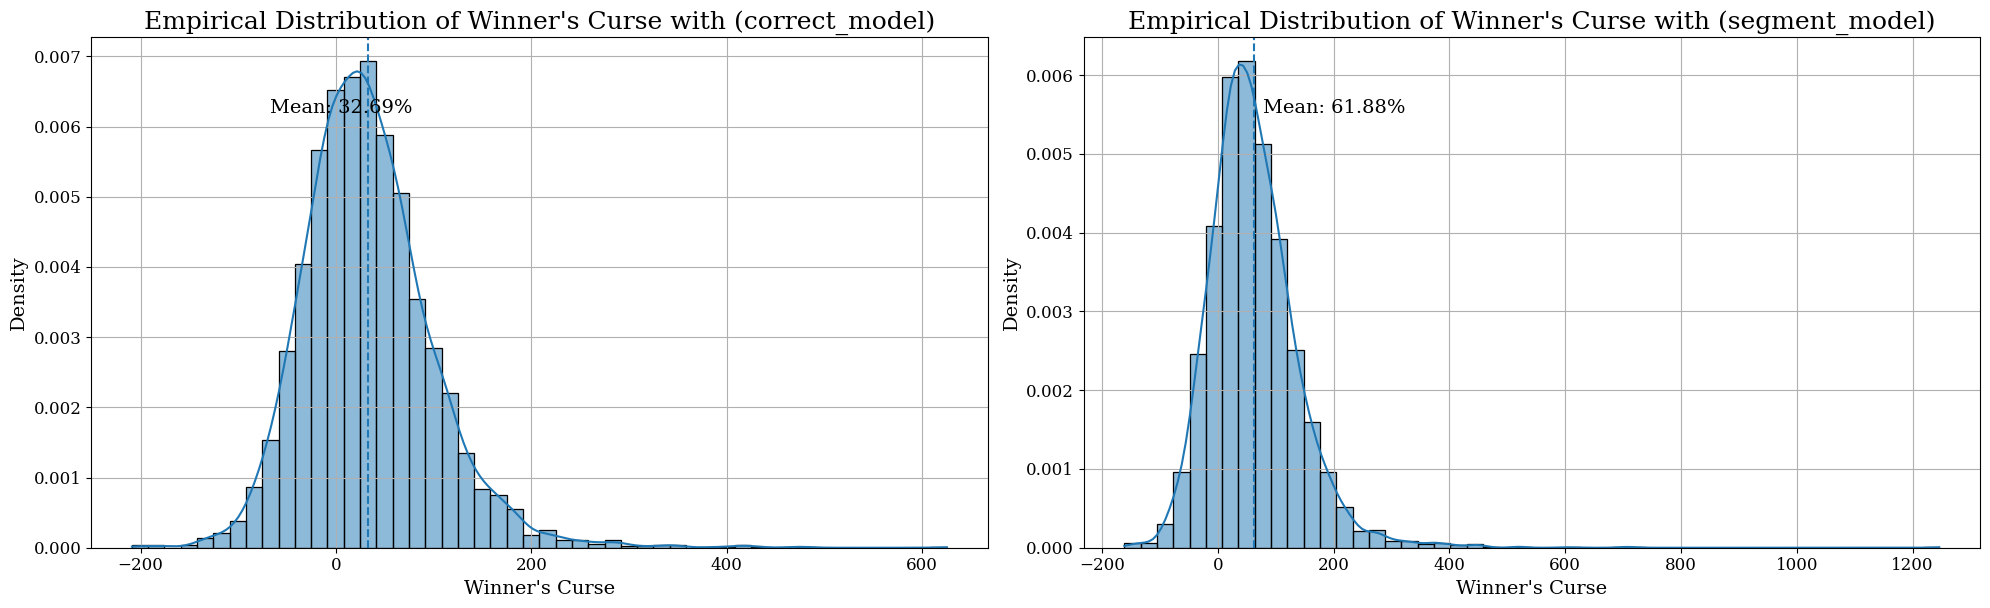

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

for idx, (demand_model, result_dict) in enumerate(wc_result_dict.items()):
    avg_wc_pct = np.nanmean(result_dict['emp_wc_pct_dstn_arr'])
    se_wc_pct = np.nanstd(result_dict['emp_wc_pct_dstn_arr']) / np.sqrt(data_params['sample_size'])

    print(f"{demand_model} has mean winner's curse of {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)")
    
    sns.histplot(result_dict['emp_wc_pct_dstn_arr'], bins=50, kde=True, stat='density', ax=axes[idx], color='C0')
    axes[idx].axvline(avg_wc_pct, color='C0', linestyle='--')
    axes[idx].annotate(
        f"Mean: {avg_wc_pct:.2f}%", 
        xy=(0.2, 0.85), xycoords='axes fraction', fontsize=axis_label_size
    )
    axes[idx].set_title(f"Empirical Distribution of Winner's Curse with ({demand_model})", fontsize=title_size)

    axes[idx].tick_params(axis='both', which='major', labelsize=tick_label_size)
    axes[idx].set_xlabel("Winner's Curse", fontsize=axis_label_size)
    axes[idx].set_ylabel('Density', fontsize=axis_label_size)
    axes[idx].grid()

plt.tight_layout()
# plt.savefig('figures/case1-winners-curse-dstn.png')
plt.show()

# Estimating winner's curse

In [16]:
dgp = ContinuousSegments(**dgp_params)
X, T, Y = dgp.sample(data_params['sample_size'], seed=1)
targ_customers = dgp.sample_individuals(data_params['n_customers'], seed=1)

## Standard bootstrap

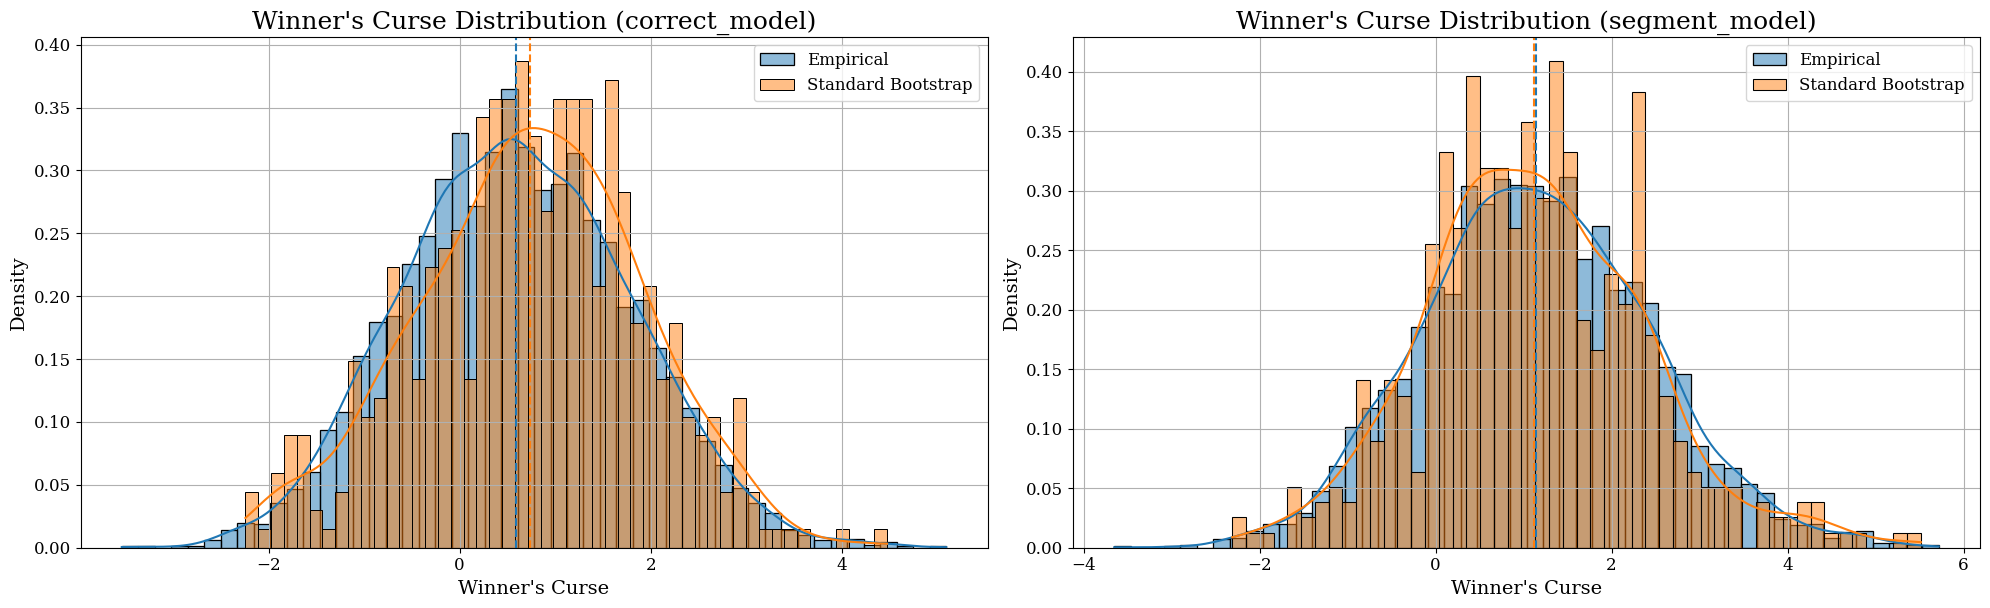

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

for idx, demand_model in enumerate(cs.demand_model_dict.keys()):
    boot_wc_dstn_arr = cs.get_wc_boot_dstn(
        X=X, T=T, Y=Y,
        targ_customers=targ_customers, treatment_space=dgp.treatment_space,
        n_bootstraps=500, demand_model=demand_model, 
        n_jobs=-1, verbose=False
    )

    # empirical winner's curse
    sns.histplot(wc_result_dict[demand_model]['emp_wc_dstn_arr'], bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=axes[idx])
    axes[idx].axvline(np.nanmean(wc_result_dict[demand_model]['emp_wc_dstn_arr']), color='C0', linestyle='--')

    # bootstrap winner's curse
    sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C1', label='Standard Bootstrap', ax=axes[idx])
    axes[idx].axvline(np.nanmean(boot_wc_dstn_arr), color='C1', linestyle='--')

    axes[idx].set_title(f'Winner\'s Curse Distribution ({demand_model})', fontsize=title_size)
    axes[idx].set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
    axes[idx].set_ylabel('Density', fontsize=axis_label_size)
    axes[idx].tick_params(labelsize=tick_label_size)
    axes[idx].legend(fontsize=legend_label_size)

    axes[idx].grid()

plt.tight_layout()
plt.show()

## m-out-of-n bootstrap

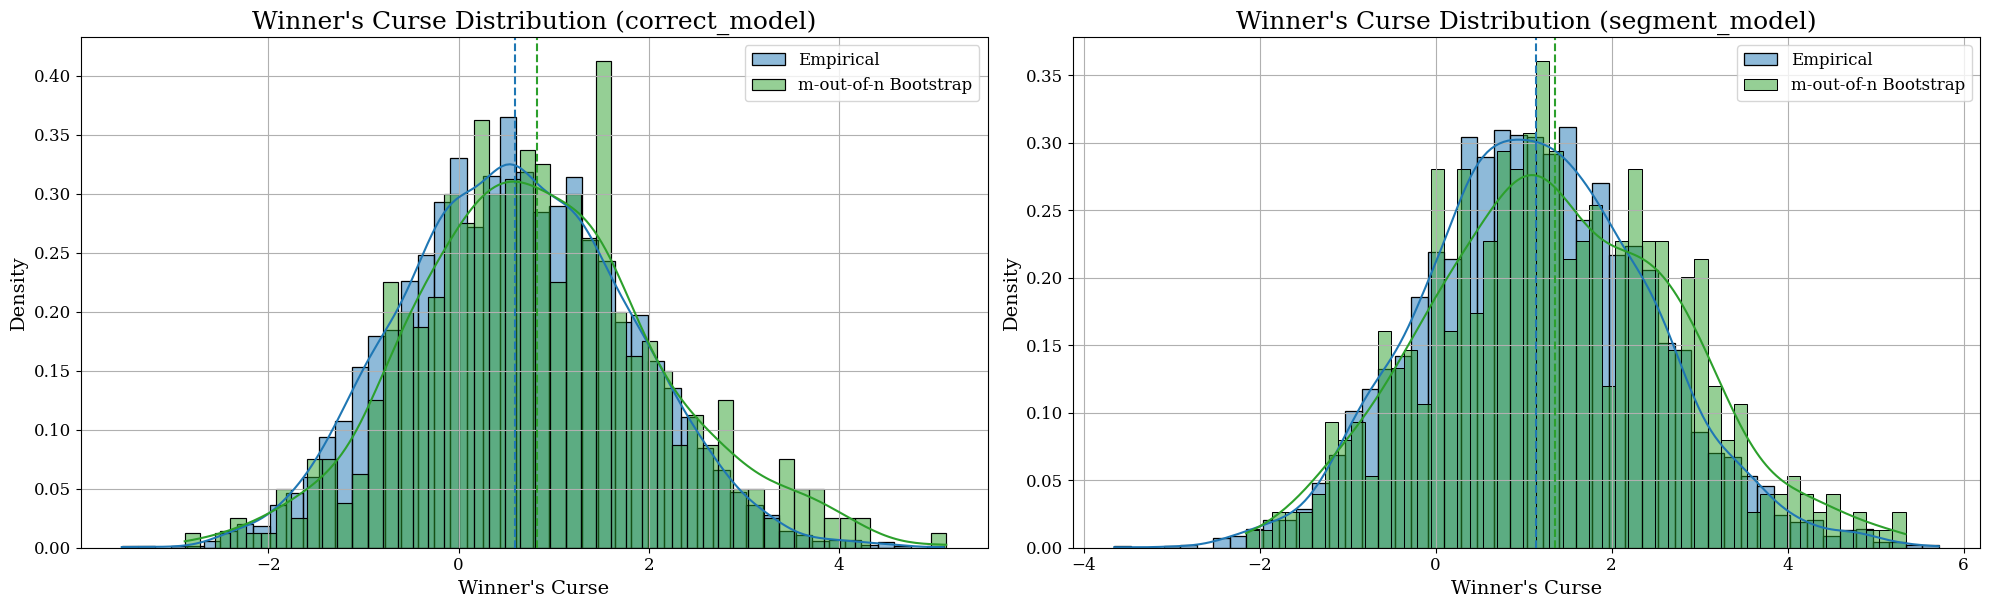

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

for idx, demand_model in enumerate(cs.demand_model_dict.keys()):
    mn_boot_wc_dstn_arr = cs.get_wc_m_out_of_n_boot_dstn(
        X=X, T=T, Y=Y,
        targ_customers=targ_customers, treatment_space=dgp.treatment_space,
        n_bootstraps=500, power=0.95, 
        demand_model=demand_model, 
        n_jobs=-1, verbose=False
    )

    # empirical winner's curse
    sns.histplot(wc_result_dict[demand_model]['emp_wc_dstn_arr'], bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=axes[idx])
    axes[idx].axvline(np.nanmean(wc_result_dict[demand_model]['emp_wc_dstn_arr']), color='C0', linestyle='--')

    # bootstrap winner's curse
    sns.histplot(mn_boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C2', label='m-out-of-n Bootstrap', ax=axes[idx])
    axes[idx].axvline(np.nanmean(mn_boot_wc_dstn_arr), color='C2', linestyle='--')

    axes[idx].set_title(f'Winner\'s Curse Distribution ({demand_model})', fontsize=title_size)
    axes[idx].set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
    axes[idx].set_ylabel('Density', fontsize=axis_label_size)
    axes[idx].tick_params(labelsize=tick_label_size)
    axes[idx].legend(fontsize=legend_label_size)

    axes[idx].grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap 

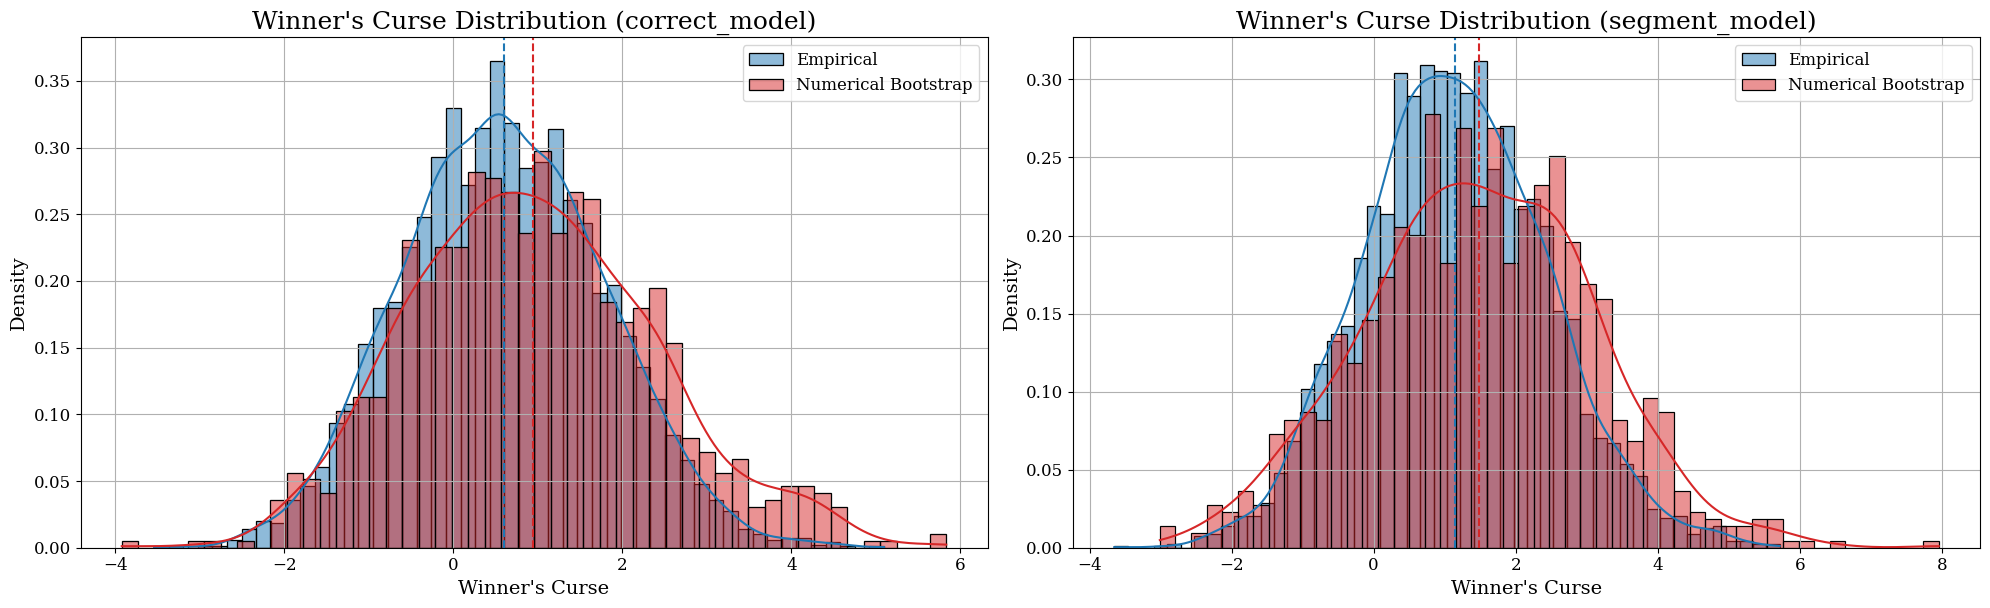

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

for idx, demand_model in enumerate(cs.demand_model_dict.keys()):
    num_boot_wc_dstn_arr = cs.get_wc_num_boot_dstn(
        X=X, T=T, Y=Y,
        targ_customers=targ_customers, treatment_space=dgp.treatment_space,
        n_bootstraps=1000, power=-0.45, 
        demand_model=demand_model, 
        n_jobs=-1, verbose=False
    )

    # empirical winner's curse
    sns.histplot(wc_result_dict[demand_model]['emp_wc_dstn_arr'], bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=axes[idx])
    axes[idx].axvline(np.nanmean(wc_result_dict[demand_model]['emp_wc_dstn_arr']), color='C0', linestyle='--')
    
    # bootstrap winner's curse
    sns.histplot(num_boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C3', label='Numerical Bootstrap', ax=axes[idx])
    axes[idx].axvline(np.nanmean(num_boot_wc_dstn_arr), color='C3', linestyle='--')

    axes[idx].set_title(f'Winner\'s Curse Distribution ({demand_model})', fontsize=title_size)
    axes[idx].set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
    axes[idx].set_ylabel('Density', fontsize=axis_label_size)
    axes[idx].tick_params(labelsize=tick_label_size)
    axes[idx].legend(fontsize=legend_label_size)

    axes[idx].grid()

plt.tight_layout()
plt.show()

# Bias Correction

## Correct Model

In [47]:
dgp_params = {
    'treatment_space': np.array([1, 2]),
    'n_features': 1,
    'alpha_lb': 0.5, 'alpha_ub': 1.5,
    'beta_lb': 1, 'beta_ub': 3,
    'noise_std': 10, 'const': 2, 
    'seed': 0
}

data_params = {'sample_size': 100, 'seed': None, 'n_customers': 100}

experiment_params = {
    'n_experiments': 1000, 
    'demand_model': 'correct_model', 
    'segment_threshold': 0
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 500, 'n_jobs': 1}
    }, 
    'mn_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 500, 'power': 0.95, 'n_jobs': 1}
    }, 
    'num_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 500, 'power': -0.45, 'n_jobs': 1}
    }
}

wc_result_dict = {key: None for key in cs.demand_model_dict.keys()}

result_records = cs.repeated_experiments(
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   12.7s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   17.1s finished


In [48]:
wc_pct_df = pd.DataFrame.from_records({
    f'{name}': 100 * np.array([record[f'{name}_wc_pct'] for record in result_records])
    for name in ['plugin'] + list(estimators_dict.keys())
})

for estimator in ['plugin'] + list(estimators_dict.keys()):
    avg_wc_pct = np.mean(wc_pct_df[estimator])
    se_wc_pct = np.std(wc_pct_df[estimator]) / np.sqrt(data_params['sample_size'])

    print(f'Winner\'s Curse MPE of {estimator}: {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)')

Winner's Curse MPE of plugin: 34.78% (6.50%)
Winner's Curse MPE of standard_bootstrap: 12.34% (6.74%)
Winner's Curse MPE of mn_bootstrap: 7.57% (6.73%)
Winner's Curse MPE of num_bootstrap: 6.78% (6.85%)


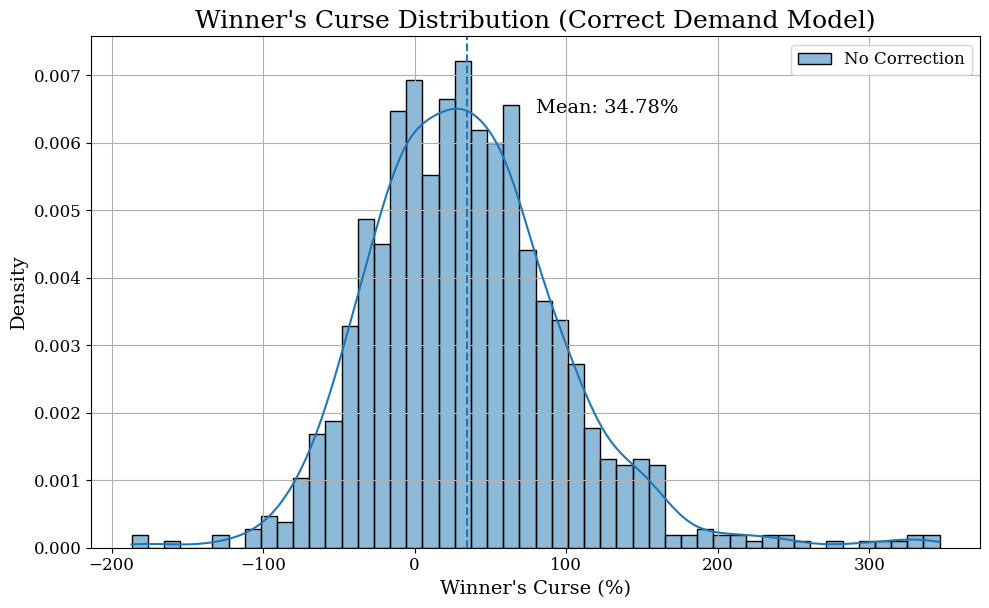

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# empirical winner's curse
sns.histplot(wc_pct_df['plugin'], bins=50, kde=True, stat='density', color='C0', label='No Correction', ax=ax)
ax.axvline(np.nanmean(wc_pct_df['plugin']), color='C0', linestyle='--')

ax.annotate(
    f"Mean: {np.mean(wc_pct_df['plugin']):.2f}%", 
    xy=(0.5, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)

ax.set_title(f'Winner\'s Curse Distribution (Correct Demand Model)', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()

plt.tight_layout()
plt.show()

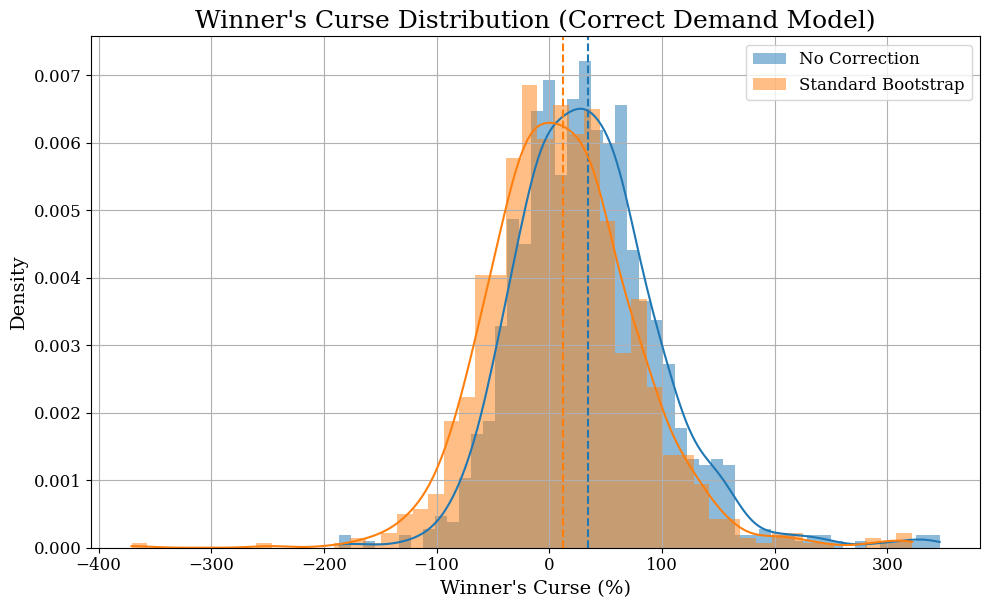

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# empirical winner's curse
sns.histplot(wc_pct_df['plugin'], bins=50, kde=True, stat='density', color='C0', label='No Correction', ax=ax, edgecolor=None)
ax.axvline(np.nanmean(wc_pct_df['plugin']), color='C0', linestyle='--')

# standard bootstrap
sns.histplot(wc_pct_df['standard_bootstrap'], bins=50, kde=True, stat='density', color='C1', label='Standard Bootstrap', ax=ax, edgecolor=None)
ax.axvline(np.nanmean(wc_pct_df['standard_bootstrap']), color='C1', linestyle='--')

ax.set_title(f'Winner\'s Curse Distribution (Correct Demand Model)', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()

plt.tight_layout()
plt.show()

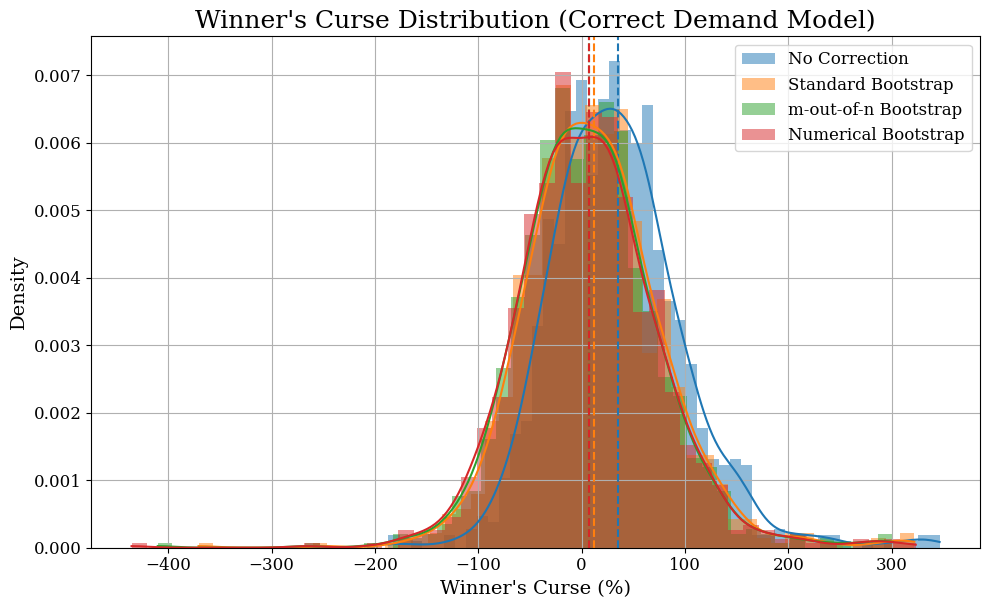

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# empirical winner's curse
sns.histplot(wc_pct_df['plugin'], bins=50, kde=True, stat='density', color='C0', label='No Correction', ax=ax, edgecolor=None)
ax.axvline(np.nanmean(wc_pct_df['plugin']), color='C0', linestyle='--')

# standard bootstrap
sns.histplot(wc_pct_df['standard_bootstrap'], bins=50, kde=True, stat='density', color='C1', label='Standard Bootstrap', ax=ax, edgecolor=None)
ax.axvline(np.nanmean(wc_pct_df['standard_bootstrap']), color='C1', linestyle='--')

# m-out-of-n bootstrap
sns.histplot(wc_pct_df['mn_bootstrap'], bins=50, kde=True, stat='density', color='C2', label='m-out-of-n Bootstrap', ax=ax, edgecolor=None)
ax.axvline(np.nanmean(wc_pct_df['mn_bootstrap']), color='C2', linestyle='--')

# numerical
sns.histplot(wc_pct_df['num_bootstrap'], bins=50, kde=True, stat='density', color='C3', label='Numerical Bootstrap', ax=ax, edgecolor=None)
ax.axvline(np.nanmean(wc_pct_df['num_bootstrap']), color='C3', linestyle='--')

ax.set_title(f'Winner\'s Curse Distribution (Correct Demand Model)', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()

plt.tight_layout()
plt.show()

## Segment Model

In [60]:
dgp_params = {
    'treatment_space': np.array([1, 2]),
    'n_features': 1,
    'alpha_lb': 0.5, 'alpha_ub': 1.5,
    'beta_lb': 1, 'beta_ub': 3,
    'noise_std': 10, 'const': 2, 
    'seed': 0
}

data_params = {'sample_size': 100, 'seed': None, 'n_customers': 100}

experiment_params = {
    'n_experiments': 1000, 
    'demand_model': 'segment_model', 
    'segment_threshold': 0, 
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 500, 'n_jobs': 1}
    }, 
    'mn_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 500, 'power': 0.90, 'n_jobs': 1}
    }, 
    'num_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 500, 'power': -0.40, 'n_jobs': 1}
    }
}

wc_result_dict = {key: None for key in cs.demand_model_dict.keys()}

result_records = cs.repeated_experiments(
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   20.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   51.6s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  2.1min finished


In [61]:
wc_pct_df = pd.DataFrame.from_records({
    f'{name}': 100 * np.array([record[f'{name}_wc_pct'] for record in result_records])
    for name in ['plugin'] + list(estimators_dict.keys())
})

for estimator in ['plugin'] + list(estimators_dict.keys()):
    avg_wc_pct = np.mean(wc_pct_df[estimator])
    se_wc_pct = np.std(wc_pct_df[estimator]) / np.sqrt(data_params['sample_size'])

    print(f'Winner\'s Curse MPE of {estimator}: {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)')

Winner's Curse MPE of plugin: 63.22% (7.08%)
Winner's Curse MPE of standard_bootstrap: 21.71% (7.26%)
Winner's Curse MPE of mn_bootstrap: 4.43% (7.24%)
Winner's Curse MPE of num_bootstrap: -2.30% (7.59%)


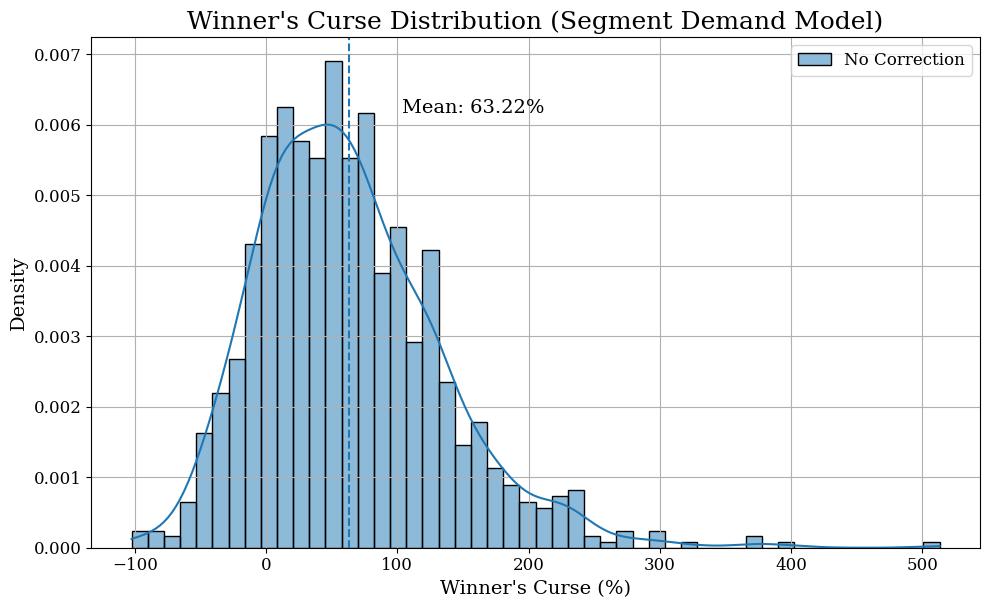

In [62]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# empirical winner's curse
sns.histplot(wc_pct_df['plugin'], bins=50, kde=True, stat='density', color='C0', label='No Correction', ax=ax)
ax.axvline(np.nanmean(wc_pct_df['plugin']), color='C0', linestyle='--')

ax.annotate(
    f"Mean: {np.mean(wc_pct_df['plugin']):.2f}%", 
    xy=(0.35, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)

ax.set_title(f'Winner\'s Curse Distribution (Segment Demand Model)', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()

plt.tight_layout()
plt.show()

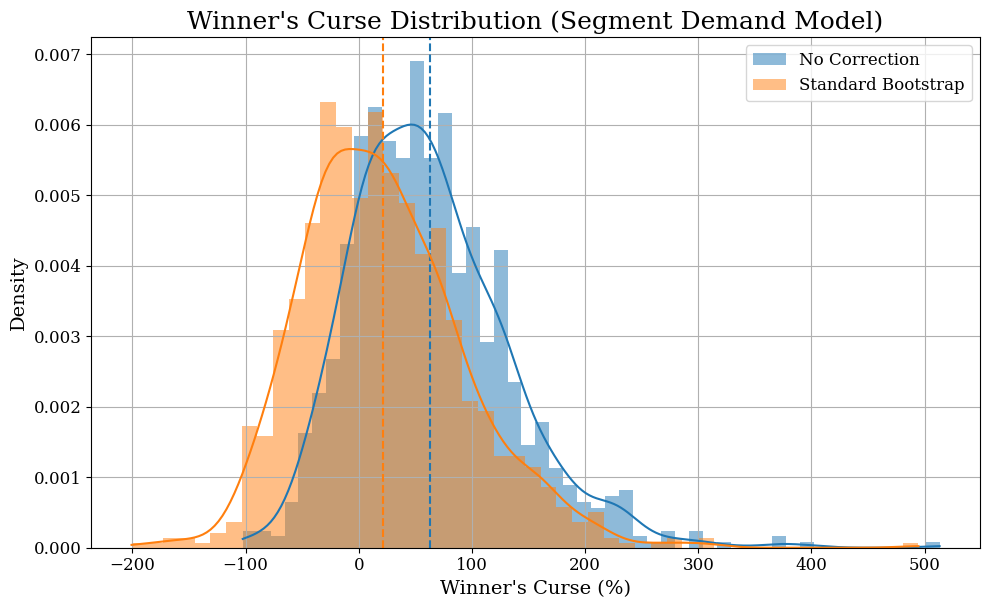

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# empirical winner's curse
sns.histplot(wc_pct_df['plugin'], bins=50, kde=True, stat='density', color='C0', label='No Correction', ax=ax, edgecolor=None)
ax.axvline(np.nanmean(wc_pct_df['plugin']), color='C0', linestyle='--')

# standard bootstrap
sns.histplot(wc_pct_df['standard_bootstrap'], bins=50, kde=True, stat='density', color='C1', label='Standard Bootstrap', ax=ax, edgecolor=None)
ax.axvline(np.nanmean(wc_pct_df['standard_bootstrap']), color='C1', linestyle='--')

ax.set_title(f'Winner\'s Curse Distribution (Segment Demand Model)', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()

plt.tight_layout()
plt.show()

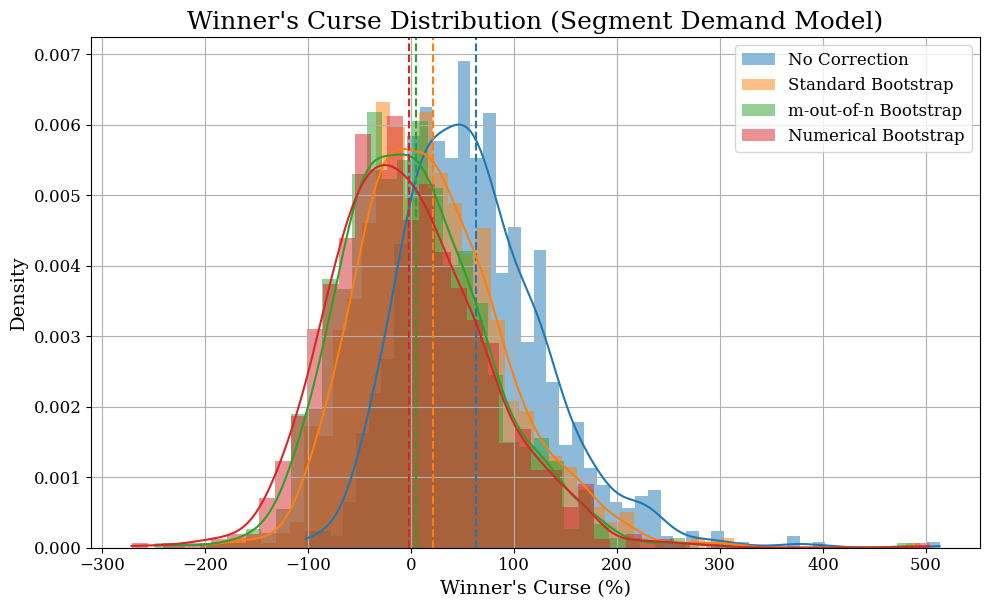

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# empirical winner's curse
sns.histplot(wc_pct_df['plugin'], bins=50, kde=True, stat='density', color='C0', label='No Correction', ax=ax, edgecolor=None)
ax.axvline(np.nanmean(wc_pct_df['plugin']), color='C0', linestyle='--')

# standard bootstrap
sns.histplot(wc_pct_df['standard_bootstrap'], bins=50, kde=True, stat='density', color='C1', label='Standard Bootstrap', ax=ax, edgecolor=None)
ax.axvline(np.nanmean(wc_pct_df['standard_bootstrap']), color='C1', linestyle='--')

# m-out-of-n bootstrap
sns.histplot(wc_pct_df['mn_bootstrap'], bins=50, kde=True, stat='density', color='C2', label='m-out-of-n Bootstrap', ax=ax, edgecolor=None)
ax.axvline(np.nanmean(wc_pct_df['mn_bootstrap']), color='C2', linestyle='--')

# numeircal
sns.histplot(wc_pct_df['num_bootstrap'], bins=50, kde=True, stat='density', color='C3', label='Numerical Bootstrap', ax=ax, edgecolor=None)
ax.axvline(np.nanmean(wc_pct_df['num_bootstrap']), color='C3', linestyle='--')

ax.set_title(f'Winner\'s Curse Distribution (Segment Demand Model)', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()

plt.tight_layout()
plt.show()

# Sensitivity Analysis